# Global Front Analysis

This notebook provides tools for:
1. Loading and characterizing ALL fronts globally
2. Selecting fronts within lat/lon bounding boxes
3. Generating PDFs (histograms) and scatter plots for selected regions

**Note:** Processing the entire globe takes time! Start with a region, then expand.

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
import xarray as xr
import pandas as pd
from pathlib import Path
import sys
from scipy.stats import gaussian_kde

sys.path.insert(0, str(Path.cwd().parent))
from group_fronts import label, geometry, io


plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
%matplotlib inline

print("Imports successful!")

Imports successful!


## 1. Load Global Data

In [32]:
# === FILE PATHS - UPDATE THESE ===
fronts_file = '/Users/lahoffma/data/fronts/global/LLC4320_2012-11-09T12_00_00_fronts.npy'
coords_file = '/Users/lahoffma/data/fronts/global/LLC_coords_lat_lon.nc'
llc_file = '/Users/lahoffma/data/fronts/global/LLC4320_2012-11-09T12_00_00.nc'
divb2_file = '/Users/lahoffma/data/fronts/global/LLC4320_2012-11-09T12_00_00_divb2.nc'

time = '2012-11-09T12:00:00'

# === LOAD GLOBAL FRONTS ===
print("Loading global fronts...")
fronts_global = np.load(fronts_file)
print(f"  Shape: {fronts_global.shape}")
print(f"  Front pixels: {np.sum(fronts_global):,}")

# === LOAD COORDINATES ===
print("\nLoading coordinates...")
ds_coords = xr.open_dataset(coords_file)
lat_global = ds_coords['lat'].values if 'lat' in ds_coords else ds_coords['YC'].values
lon_global = ds_coords['lon'].values if 'lon' in ds_coords else ds_coords['XC'].values

print(f"  Original Lat range: [{lat_global.min():.1f}, {lat_global.max():.1f}]")
print(f"  Original Lon range: [{lon_global.min():.1f}, {lon_global.max():.1f}]")

# Find which column has the minimum longitude (for a representative row)
sample_row = lat_global.shape[0] // 2  # Middle row
lon_row = lon_global[sample_row, :]
min_lon_col = np.argmin(lon_row)
print(f"  Minimum longitude is at column {min_lon_col}, value: {lon_row[min_lon_col]:.1f}°")

# Roll arrays so minimum longitude is at column 0
# This makes the data go from min→max longitude in column order
if min_lon_col != 0:
    shift = -min_lon_col  # Negative to roll left
    print(f"  Rolling arrays by {shift} columns to align with longitude axis...")
    
    lon_global = np.roll(lon_global, shift, axis=1)
    lat_global = np.roll(lat_global, shift, axis=1)
    fronts_global = np.roll(fronts_global, shift, axis=1)
    
    # Verify
    lon_row_new = lon_global[sample_row, :]
    print(f"  After rolling: column 0 = {lon_row_new[0]:.1f}°, column -1 = {lon_row_new[-1]:.1f}°")

ds_coords.close()

# === LOAD FIELDS ===
print("\nLoading fields...")
ds_llc = xr.open_dataset(llc_file)
ds_divb2 = xr.open_dataset(divb2_file)

fields_global = {
    'theta': ds_llc['Theta'].values,
    'salt': ds_llc['Salt'].values,
    'u': ds_llc['U'].values if 'U' in ds_llc else None,
    'v': ds_llc['V'].values if 'V' in ds_llc else None,
    'w': ds_llc['W'].values if 'W' in ds_llc else None,
    'ssh': ds_llc['Eta'].values if 'Eta' in ds_llc else None,
    'divb2': ds_divb2['Divb2'].values
}

# Roll field arrays to match
if min_lon_col != 0:
    print("\nRolling field arrays...")
    for name, field in fields_global.items():
        if field is not None:
            fields_global[name] = np.roll(field, shift, axis=1)

for name, field in fields_global.items():
    if field is not None:
        print(f"  {name}: {field.shape}")

ds_llc.close()
ds_divb2.close()

print("\n✓ Data loaded and reordered so columns go min→max longitude!")

Loading global fronts...
  Shape: (12960, 17280)
  Front pixels: 4,121,694

Loading coordinates...
  Original Lat range: [-90.0, 72.0]
  Original Lon range: [-180.0, 180.0]
  Minimum longitude is at column 10464, value: -180.0°
  Rolling arrays by -10464 columns to align with longitude axis...
  After rolling: column 0 = -180.0°, column -1 = 180.0°

Loading fields...

Rolling field arrays...
  theta: (12960, 17280)
  salt: (12960, 17280)
  u: (12960, 17280)
  v: (12960, 17280)
  w: (12960, 17280)
  ssh: (12960, 17280)
  divb2: (12960, 17280)

✓ Data loaded and reordered so columns go min→max longitude!


## 2. Process Entire Globe or Region

**Warning:** Processing the entire globe can take 30+ minutes!

Choose one:
- **Option A**: Process entire globe (slow but comprehensive)
- **Option B**: Process a specific region by lat/lon bounds (recommended)
- **Option C**: Process a region by pixel size (fast, good for testing)

In [33]:
# === PROCESSING OPTIONS ===

# Option A: Process entire globe
PROCESS_ENTIRE_GLOBE = False  # Set to True to process everything

# Option B: Process specific region (lat/lon bounds)
USE_REGION = False
region_bounds = {
    'lat_min': -5,
    'lat_max': 5,
    'lon_min': -170,
    'lon_max': -160
}

# Option C: Process region by pixel size
USE_PIXEL_REGION = True
pixel_region = {
    'center_lat': 0,      # Center latitude
    'center_lon': -165,   # Center longitude
    'height': 500,        # Height in pixels
    'width': 500          # Width in pixels
}

# === EXTRACT REGION OR USE FULL DATA ===
if PROCESS_ENTIRE_GLOBE:
    print("Processing ENTIRE GLOBE...")
    fronts_to_process = fronts_global
    lat_to_process = lat_global
    lon_to_process = lon_global
    fields_to_process = fields_global
    region_name = "Global"
    i_min, i_max, j_min, j_max = 0, fronts_global.shape[0], 0, fronts_global.shape[1]

elif USE_REGION:
    print(f"Processing region: lat=[{region_bounds['lat_min']}, {region_bounds['lat_max']}], "
          f"lon=[{region_bounds['lon_min']}, {region_bounds['lon_max']}]")

    # Find indices within bounds
    lat_mask = (lat_global >= region_bounds['lat_min']) & (lat_global <= region_bounds['lat_max'])
    lon_mask = (lon_global >= region_bounds['lon_min']) & (lon_global <= region_bounds['lon_max'])
    region_mask = lat_mask & lon_mask

    # Get bounding box
    rows, cols = np.where(region_mask)
    i_min, i_max = rows.min(), rows.max() + 1
    j_min, j_max = cols.min(), cols.max() + 1

    print(f"  Extracting indices: [{i_min}:{i_max}, {j_min}:{j_max}]")

    # Extract region
    fronts_to_process = fronts_global[i_min:i_max, j_min:j_max]
    lat_to_process = lat_global[i_min:i_max, j_min:j_max]
    lon_to_process = lon_global[i_min:i_max, j_min:j_max]

    fields_to_process = {}
    for name, field in fields_global.items():
        if field is not None:
            fields_to_process[name] = field[i_min:i_max, j_min:j_max]

    region_name = f"Region_lat{region_bounds['lat_min']}to{region_bounds['lat_max']}_lon{region_bounds['lon_min']}to{region_bounds['lon_max']}"

elif USE_PIXEL_REGION:
    print(f"Processing pixel region: center=({pixel_region['center_lat']:.1f}, {pixel_region['center_lon']:.1f}), "
          f"size={pixel_region['height']}x{pixel_region['width']} pixels")
    
    # Find pixel indices closest to center point
    center_dist = np.sqrt((lat_global - pixel_region['center_lat'])**2 + 
                          (lon_global - pixel_region['center_lon'])**2)
    center_i, center_j = np.unravel_index(np.argmin(center_dist), center_dist.shape)
    
    print(f"  Center pixel: ({center_i}, {center_j})")
    print(f"  Center coordinates: lat={lat_global[center_i, center_j]:.2f}, lon={lon_global[center_i, center_j]:.2f}")
    
    # Calculate bounding box
    half_height = pixel_region['height'] // 2
    half_width = pixel_region['width'] // 2
    
    i_min = max(0, center_i - half_height)
    i_max = min(fronts_global.shape[0], center_i + half_height)
    j_min = max(0, center_j - half_width)
    j_max = min(fronts_global.shape[1], center_j + half_width)
    
    print(f"  Extracting indices: [{i_min}:{i_max}, {j_min}:{j_max}]")
    print(f"  Actual size: {i_max - i_min} x {j_max - j_min} pixels")
    
    # Extract region
    fronts_to_process = fronts_global[i_min:i_max, j_min:j_max]
    lat_to_process = lat_global[i_min:i_max, j_min:j_max]
    lon_to_process = lon_global[i_min:i_max, j_min:j_max]
    
    fields_to_process = {}
    for name, field in fields_global.items():
        if field is not None:
            fields_to_process[name] = field[i_min:i_max, j_min:j_max]
    
    # Get actual lat/lon bounds
    actual_lat_min, actual_lat_max = lat_to_process.min(), lat_to_process.max()
    actual_lon_min, actual_lon_max = lon_to_process.min(), lon_to_process.max()
    region_bounds = {
        'lat_min': actual_lat_min,
        'lat_max': actual_lat_max,
        'lon_min': actual_lon_min,
        'lon_max': actual_lon_max
    }
    
    region_name = f"PixelRegion_{pixel_region['height']}x{pixel_region['width']}_center{pixel_region['center_lat']:.0f}N{pixel_region['center_lon']:.0f}E"
    print(f"  Actual bounds: lat=[{actual_lat_min:.2f}, {actual_lat_max:.2f}], lon=[{actual_lon_min:.2f}, {actual_lon_max:.2f}]")

print(f"\nProcessing area: {fronts_to_process.shape}")
print(f"Front pixels in area: {np.sum(fronts_to_process):,}")

Processing pixel region: center=(0.0, -165.0), size=500x500 pixels
  Center pixel: (7919, 719)
  Center coordinates: lat=-0.01, lon=-165.01
  Extracting indices: [7669:8169, 469:969]
  Actual size: 500 x 500 pixels
  Actual bounds: lat=[-4.83, 4.80], lon=[-170.22, -159.82]

Processing area: (500, 500)
Front pixels in area: 6,109


### 2a. Visualize Selected Region

Before processing, visualize:
- (a) Where the selected region is on the globe
- (b) What the raw front detection looks like in this region

Extent: lon=[-180.0, 180.0], lat=[-90.0, 72.0]


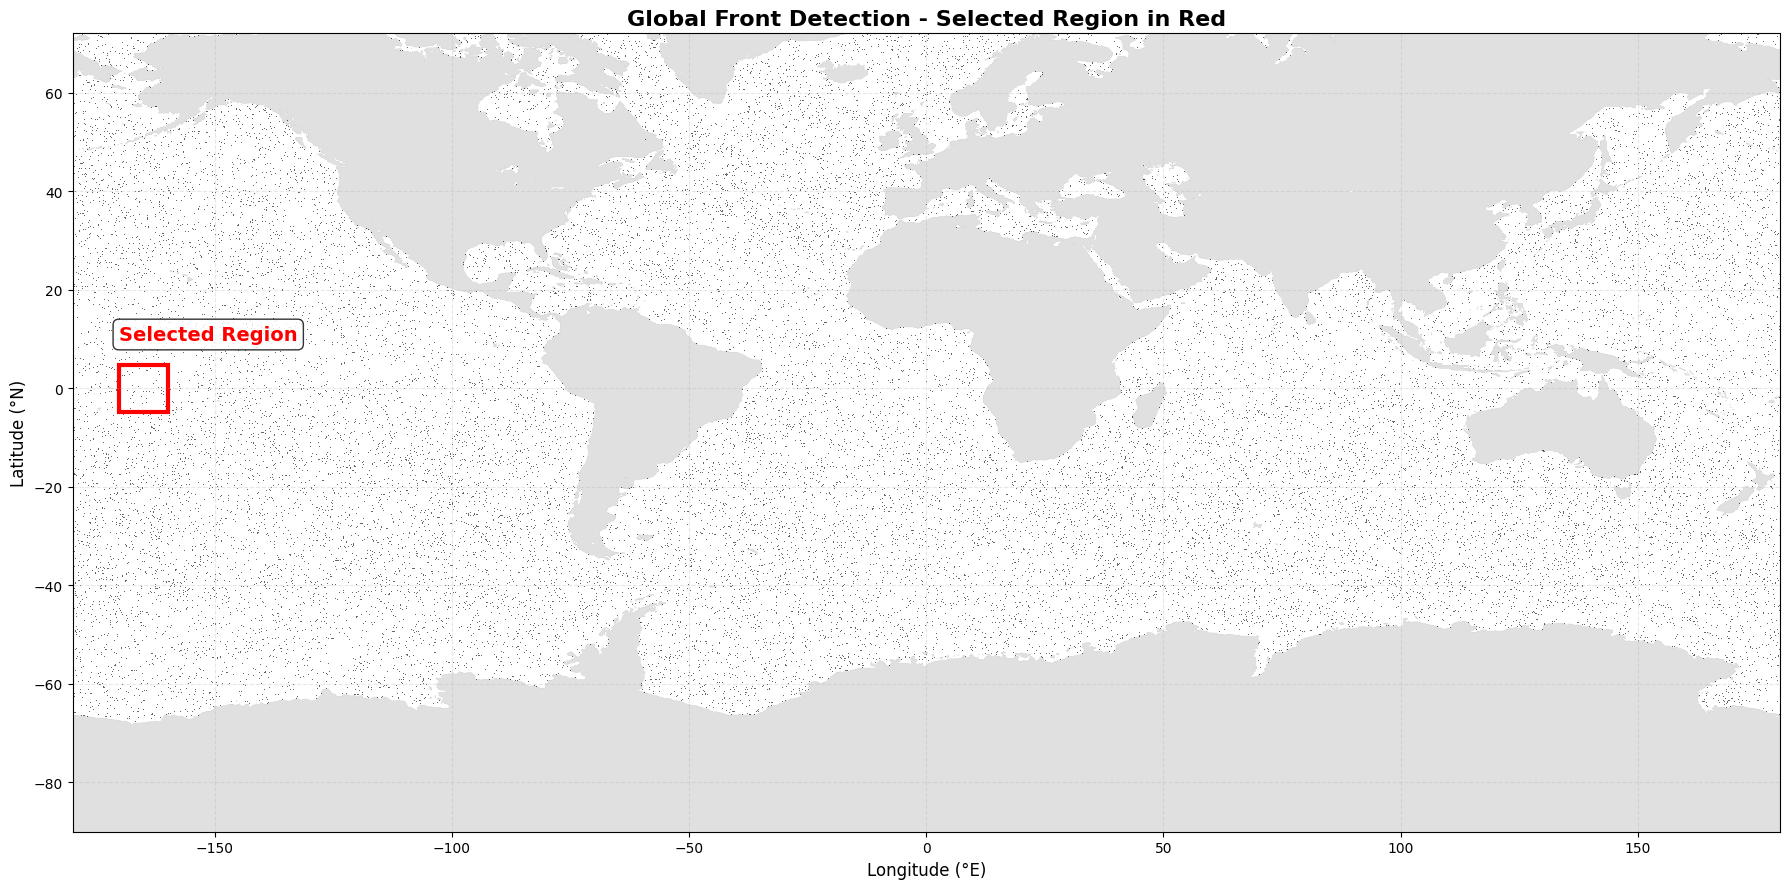

✓ Map (a): Global map with data reordered to match longitude axis


In [34]:
# === (a) GLOBAL CONTEXT MAP ===
# Show where the selected region is on the whole globe

fig, ax = plt.subplots(figsize=(18, 9))

# Downsample for faster plotting
downsample = 10
fronts_display = fronts_global[::downsample, ::downsample]

# Create land mask
ocean_mask = (fields_global['divb2'] > 0) | (np.abs(fields_global['theta']) > 0.1)
land_mask_display = ~ocean_mask[::downsample, ::downsample]

# Use full coordinate arrays for extent
extent_global = [lon_global.min(), lon_global.max(), 
                 lat_global.min(), lat_global.max()]

print(f"Extent: lon=[{extent_global[0]:.1f}, {extent_global[1]:.1f}], lat=[{extent_global[2]:.1f}, {extent_global[3]:.1f}]")

# Plot land mask (gray)
land_rgba = np.zeros((*land_mask_display.shape, 4))
land_rgba[land_mask_display] = [0.7, 0.7, 0.7, 1.0]
ax.imshow(land_rgba, extent=extent_global, origin='lower', aspect='auto')

# Plot fronts
ax.imshow(fronts_display, extent=extent_global, origin='lower',
          aspect='auto', cmap='gray_r', alpha=0.6, interpolation='nearest')

# Red box for selected region (works for both Option B and Option C)
if USE_REGION or USE_PIXEL_REGION:
    rect = Rectangle(
        (region_bounds['lon_min'], region_bounds['lat_min']),
        region_bounds['lon_max'] - region_bounds['lon_min'],
        region_bounds['lat_max'] - region_bounds['lat_min'],
        fill=False, edgecolor='red', linewidth=3, linestyle='-'
    )
    ax.add_patch(rect)
    
    ax.text(
        region_bounds['lon_min'], region_bounds['lat_max'] + 5,
        'Selected Region',
        color='red', fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.set_title('Global Front Detection - Selected Region in Red', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"✓ Map (a): Global map with data reordered to match longitude axis")

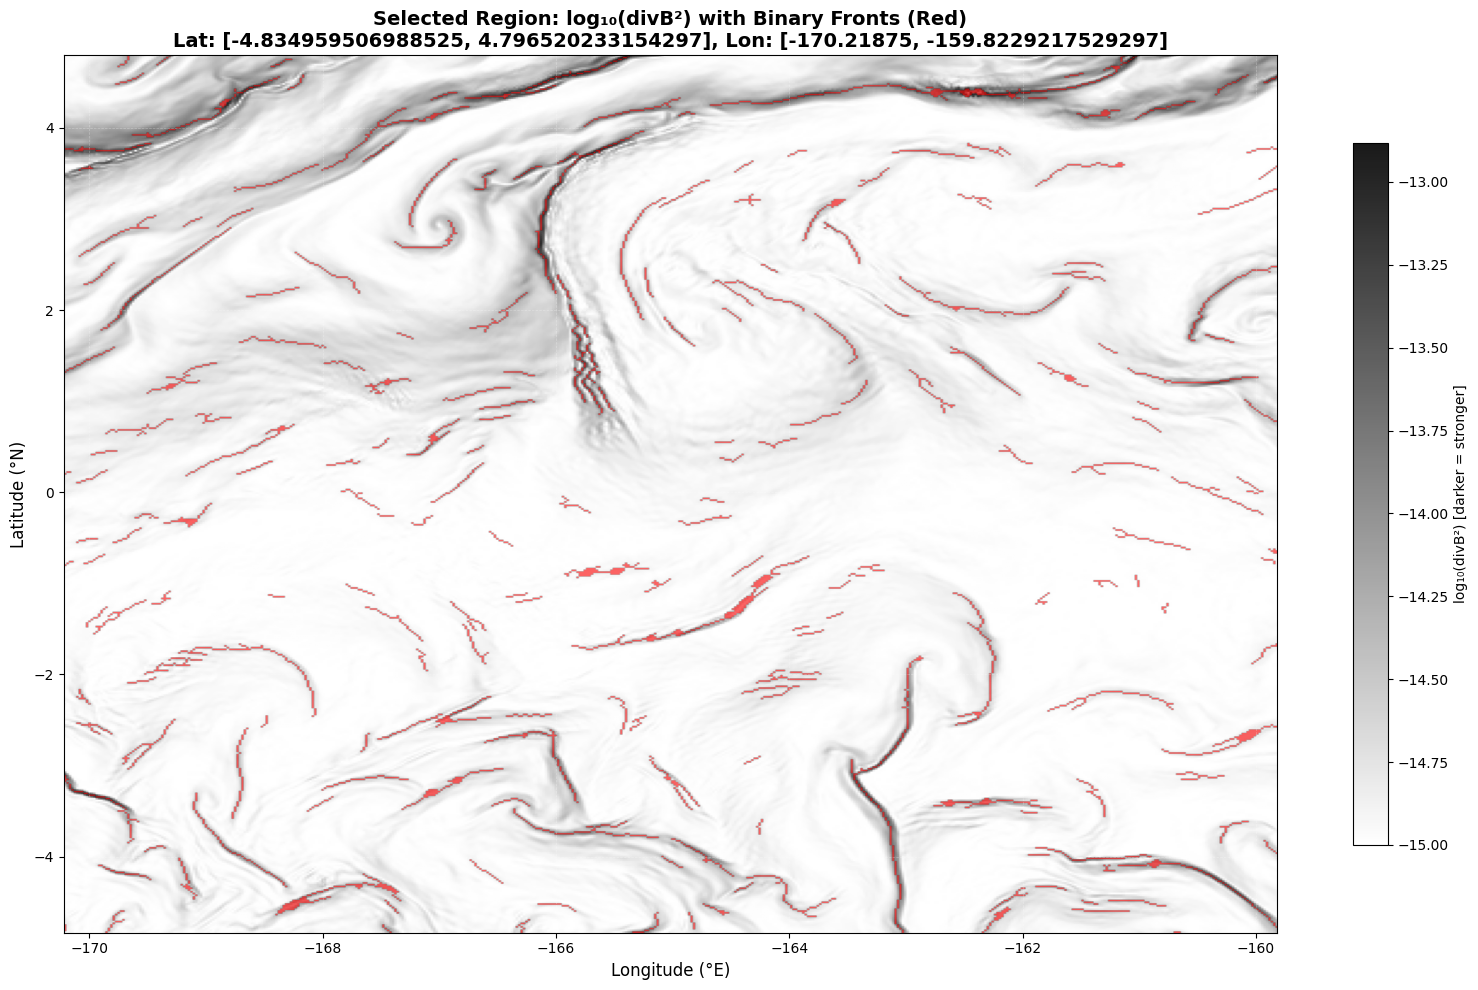

✓ Map (b): Regional map with coordinate labels from LLC_coords.nc
  Front pixels in region: 6,109


In [35]:
# === (b) REGIONAL DETAIL MAP ===
# Show log(divB2) with binary fronts overlaid for the selected region

fig, ax = plt.subplots(figsize=(16, 10))

# Use ACTUAL coordinate min/max from the coordinate arrays
extent_region = [lon_to_process.min(), lon_to_process.max(),
                 lat_to_process.min(), lat_to_process.max()]

# Plot log10(divB2) in grayscale (darker = stronger)
divb2_regional = fields_to_process['divb2']
divb2_log = np.log10(divb2_regional + 1e-15)

im = ax.imshow(divb2_log, extent=extent_region, origin='lower',
               aspect='auto', cmap='gray_r', alpha=0.9)
cbar = plt.colorbar(im, ax=ax, label='log₁₀(divB²) [darker = stronger]', shrink=0.8)

# Overlay binary fronts in red
fronts_rgba = np.zeros((*fronts_to_process.shape, 4))
fronts_rgba[fronts_to_process > 0] = [1, 0, 0, 0.6]

ax.imshow(fronts_rgba, extent=extent_region, origin='lower', aspect='auto')

ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.set_title(f'Selected Region: log₁₀(divB²) with Binary Fronts (Red)\n'
             f'Lat: [{region_bounds["lat_min"]}, {region_bounds["lat_max"]}], '
             f'Lon: [{region_bounds["lon_min"]}, {region_bounds["lon_max"]}]',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', color='white', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"✓ Map (b): Regional map with coordinate labels from LLC_coords.nc")
print(f"  Front pixels in region: {np.sum(fronts_to_process):,}")

## 3. Label and Characterize Fronts

In [37]:
# Label fronts
print("Labeling fronts...")
labeled, num_fronts = label.label_fronts(fronts_to_process, connectivity=2, return_num=True)
print(f"  Initial fronts: {num_fronts}")

# Filter small fronts
labeled = label.filter_fronts_by_size(labeled, min_size=10)
num_filtered = len(label.get_front_labels(labeled))
print(f"  After filtering (min_size=10): {num_filtered}")

# Generate IDs
print("\nGenerating front IDs...")
front_ids = label.generate_front_ids(labeled, lat_to_process, lon_to_process, time)
print(f"  Generated {len(front_ids)} IDs")

Labeling fronts...
  Initial fronts: 212
  After filtering (min_size=10): 162

Generating front IDs...
  Generated 162 IDs


### Map: Color-Coded Fronts

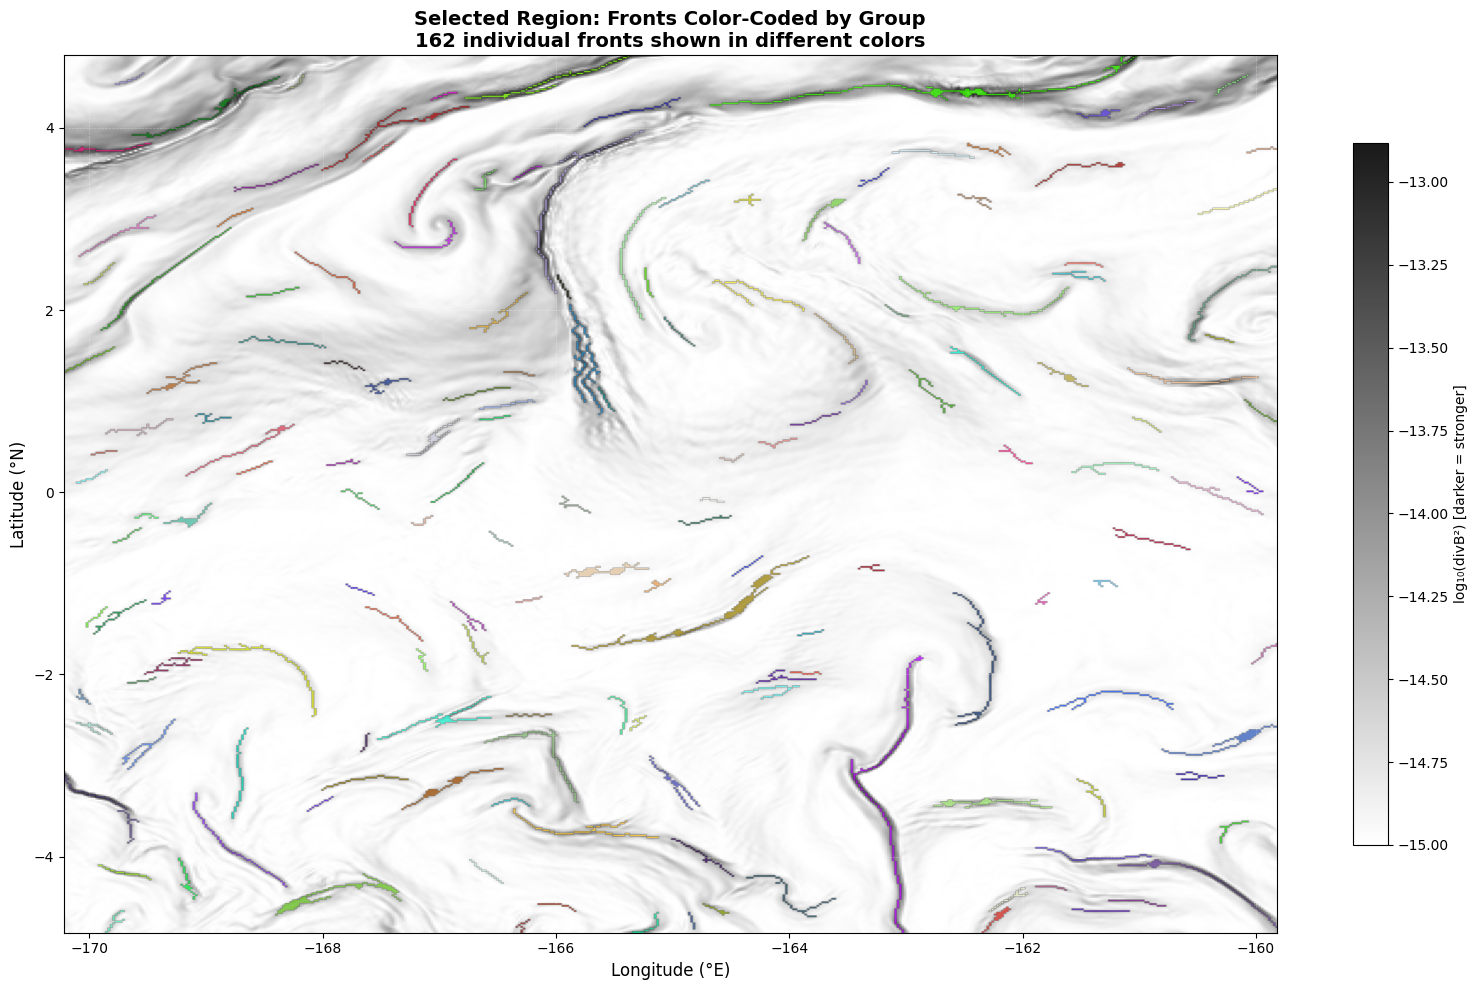

✓ Plotted 162 fronts, each in a unique color


In [38]:
# Plot selected region with each front in a different color

fig, ax = plt.subplots(figsize=(16, 10))

# Regional extent
extent_region = [lon_to_process.min(), lon_to_process.max(),
                 lat_to_process.min(), lat_to_process.max()]

# Plot log10(divB2) in grayscale (darker = stronger)
divb2_regional = fields_to_process['divb2']
divb2_log = np.log10(divb2_regional + 1e-15)

im = ax.imshow(divb2_log, extent=extent_region, origin='lower',
               aspect='auto', cmap='gray_r', alpha=0.9)
cbar = plt.colorbar(im, ax=ax, label='log₁₀(divB²) [darker = stronger]', shrink=0.8)

# Color-code each front with a random color
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

# Get unique front labels
front_labels = label.get_front_labels(labeled)
n_fronts = len(front_labels)

# Create random colormap
np.random.seed(42)  # For reproducibility
colors = np.random.rand(n_fronts, 3)  # Random RGB colors

# Create colored front array
colored_fronts = np.zeros((*labeled.shape, 3))
for idx, lbl in enumerate(front_labels):
    mask = labeled == lbl
    colored_fronts[mask] = colors[idx]

# Create RGBA array (add alpha channel)
fronts_rgba = np.zeros((*labeled.shape, 4))
fronts_rgba[..., :3] = colored_fronts
fronts_rgba[..., 3] = (labeled > 0).astype(float) * 0.8  # Alpha = 0.8 where fronts exist

ax.imshow(fronts_rgba, extent=extent_region, origin='lower', aspect='auto')

ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.set_title(f'Selected Region: Fronts Color-Coded by Group\n'
             f'{n_fronts} individual fronts shown in different colors',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', color='white', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"✓ Plotted {n_fronts} fronts, each in a unique color")

## 3a. Calculate Geometric Properties

In [39]:
# Calculate geometric properties
print("Calculating geometric properties...")
geom_props = geometry.calculate_all_geometric_properties(
    labeled, lat_to_process, lon_to_process, time, include_curvature=True
)

# Convert to DataFrame
df_geom = io.properties_to_dataframe(geom_props, front_ids)
print(f"✓ {len(df_geom)} fronts × {len(df_geom.columns)} geometric properties")
display(df_geom.head())


Calculating geometric properties...
✓ 162 fronts × 16 geometric properties


,label,front_id,time,npix,centroid_lat,centroid_lon,length_km,orientation,lat_min,lat_max,lon_min,lon_max,lat_range,lon_range,mean_curvature,curvature_direction
0,1,20121109T120000_4.7S_169.8W,2012-11-09T12:00:00,17,-4.711712,-169.788605,53.829452,63.390178,-4.83496,-4.604277,-169.864578,-169.718750,0.230683,0.145828,0.065845,0.030110
1,2,20121109T120000_4.8S_166.3W,2012-11-09T12:00:00,10,-4.765765,-166.293747,24.744539,64.902786,-4.83496,-4.700408,-166.343750,-166.239578,0.134551,0.104172,NaN,NaN
2,3,20121109T120000_4.8S_165.2W,2012-11-09T12:00:00,18,-4.761276,-165.202560,39.068148,48.729638,-4.83496,-4.623505,-165.343750,-165.135422,0.211455,0.208328,0.037383,0.037383
3,4,20121109T120000_3.4S_163.3W,2012-11-09T12:00:00,177,-3.261342,-163.130356,614.694452,88.079764,-4.83496,-1.808780,-163.468750,-162.864578,3.026179,0.604172,0.022408,0.000830
4,5,20121109T120000_4.7S_162.2W,2012-11-09T12:00:00,30,-4.669002,-162.213181,46.477856,53.140116,-4.83496,-4.565818,-162.343750,-162.114578,0.269141,0.229172,0.003849,-0.003847


### Plot Geometric Properties

Plot PDFs (probability density functions) for the geometric properties of fronts in the selected region (from Options A, B, or C above).

Plotting properties for 162 fronts in selected region:
  Lat: [-4.83, 4.80]
  Lon: [-170.22, -159.82]


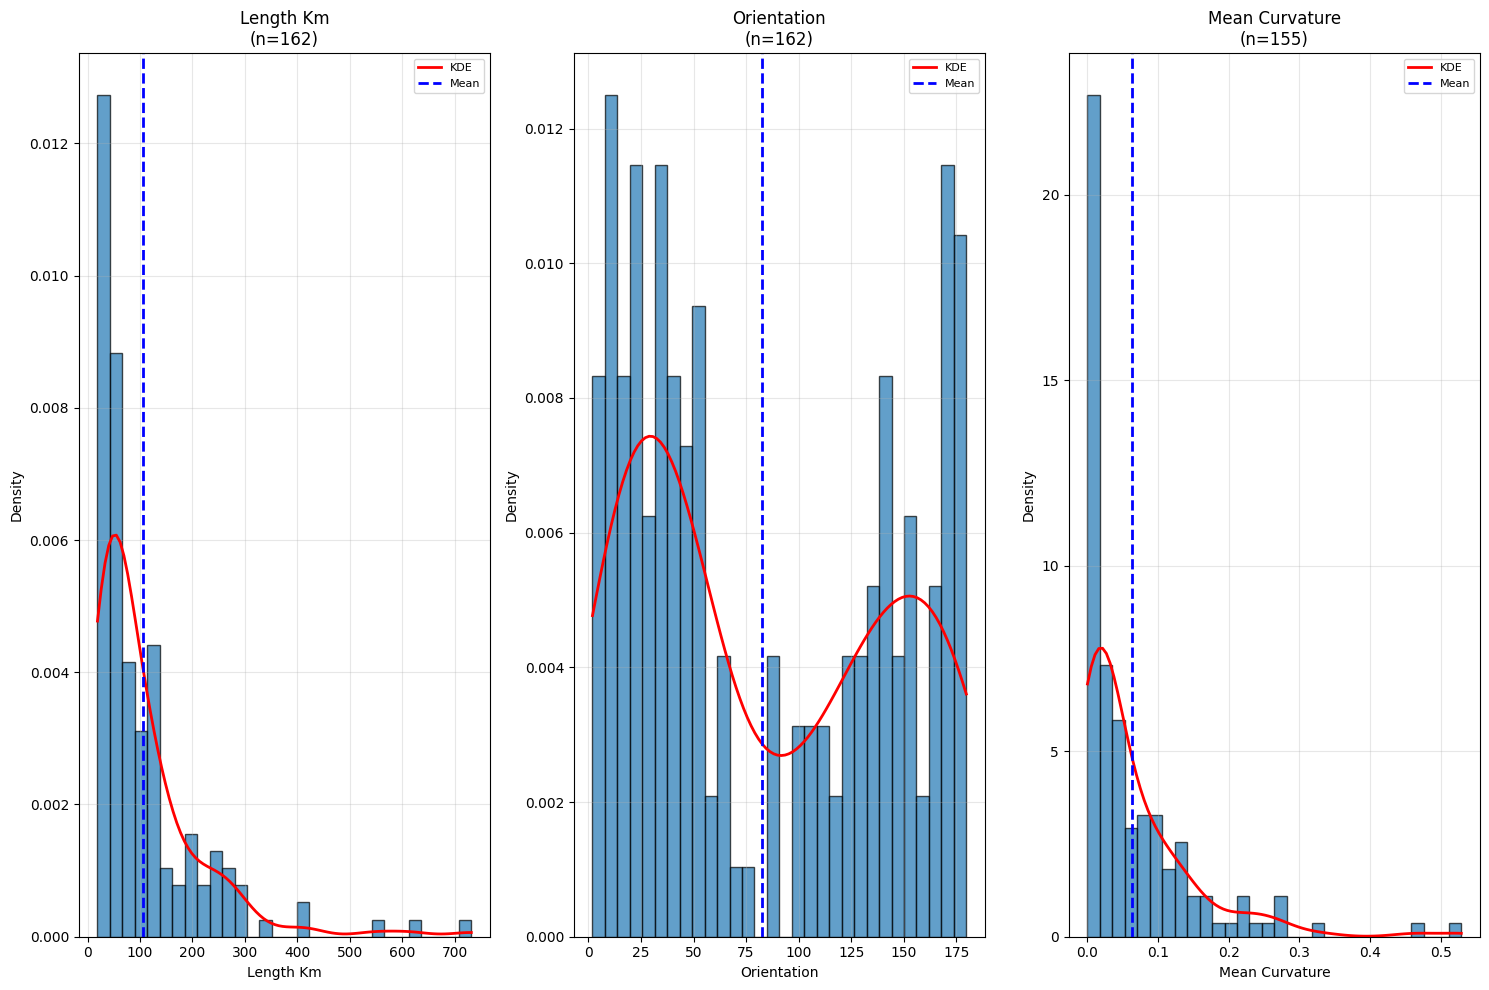

In [40]:
# Use the region that was already selected above (Options A, B, or C)
# No need to redefine bounds - they're already set!

if PROCESS_ENTIRE_GLOBE:
    # For global processing, use all fronts
    df_geom_selected = df_geom
    print(f"Plotting properties for ALL {len(df_geom_selected)} fronts globally")
else:
    # For regional processing (Options B or C), filter to the selected region
    df_geom_selected = df_geom[
        (df_geom['centroid_lat'] >= region_bounds['lat_min']) &
        (df_geom['centroid_lat'] <= region_bounds['lat_max']) &
        (df_geom['centroid_lon'] >= region_bounds['lon_min']) &
        (df_geom['centroid_lon'] <= region_bounds['lon_max'])
    ]
    print(f"Plotting properties for {len(df_geom_selected)} fronts in selected region:")
    print(f"  Lat: [{region_bounds['lat_min']:.2f}, {region_bounds['lat_max']:.2f}]")
    print(f"  Lon: [{region_bounds['lon_min']:.2f}, {region_bounds['lon_max']:.2f}]")

# Plot PDFs
from scipy.stats import gaussian_kde

def plot_pdfs(df, properties, ncols=3, figsize=(15, 10)):
    nrows = int(np.ceil(len(properties) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes
    
    for idx, prop in enumerate(properties):
        ax = axes[idx]
        if prop not in df.columns:
            ax.text(0.5, 0.5, f'{prop}\nnot available', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        # Check if column is numeric
        if not pd.api.types.is_numeric_dtype(df[prop]):
            ax.text(0.5, 0.5, f'{prop}\n(non-numeric)', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        data = df[prop].dropna()
        if len(data) == 0:
            ax.text(0.5, 0.5, f'{prop}\nno data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        ax.hist(data, bins=30, alpha=0.7, edgecolor='black', density=True)
        
        if len(data) > 10:
            try:
                kde = gaussian_kde(data)
                x_range = np.linspace(data.min(), data.max(), 100)
                ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
            except:
                pass
        
        ax.axvline(data.mean(), color='blue', linestyle='--', linewidth=2, label='Mean')
        ax.set_xlabel(prop.replace('_', ' ').title())
        ax.set_ylabel('Density')
        ax.set_title(f'{prop.replace("_", " ").title()}\n(n={len(data)})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    for idx in range(len(properties), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    return fig

# Plot geometric properties
geom_to_plot = ['length_km', 'orientation', 'mean_curvature']
fig = plot_pdfs(df_geom_selected, geom_to_plot)
plt.show()